# 01 · Problem Framing, Data Splits & Leakage

[← Course home](../README.md)

Before any model is trained, three decisions determine whether a project succeeds:
**what** exactly we predict (and how we score it), **how** we hold data back to measure honest
performance, and **whether** information from the future or from the answer sneaks into our features.

**What you will learn**

- How to frame a problem: supervised vs unsupervised, regression vs classification, target and metric.
- How to tie a metric to a real (business or physical) cost, and why a *baseline* comes first.
- Why we need three data sets (train / validation / test), and how stratification works.
- Random vs group vs time-based splits (`GroupShuffleSplit`, `GroupKFold`, `TimeSeriesSplit`).
- Three leakage demos: feature selection on noise, a target-leaking column, and preprocessing on all data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score, KFold, StratifiedKFold,
                                     GroupShuffleSplit, GroupKFold, TimeSeriesSplit)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error

from mlaz import set_style, savefig, PALETTE, load_titanic, load_mpg

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.width", 120)

## 1. Framing the problem

| Question | Answer for Titanic | Answer for Auto-MPG |
|---|---|---|
| Do we have labels? | yes → **supervised** | yes → **supervised** |
| What is the target type? | binary `survived` → **classification** | continuous `mpg` → **regression** |
| What will the prediction be used for? | e.g. prioritising rescue resources | e.g. estimating fuel cost of a design |
| What does an error cost? | missing a survivor ≠ false alarm | 1 mpg error ≈ money per km |

If there were no labels (e.g. "group these cars into families") the problem would be **unsupervised**
(clustering, dimensionality reduction) — see chapter 10.

In [2]:
titanic = load_titanic()
mpg = load_mpg()
print(titanic.shape, mpg.shape)
titanic.head()

(891, 15) (398, 9)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Titanic target balance:\n", titanic["survived"].value_counts(normalize=True).round(3))
print("\nMPG target summary:\n", mpg["mpg"].describe().round(2))

Titanic target balance:
 survived
0    0.616
1    0.384
Name: proportion, dtype: float64

MPG target summary:
 count    398.00
mean      23.51
std        7.82
min        9.00
25%       17.50
50%       23.00
75%       29.00
max       46.60
Name: mpg, dtype: float64


## 2. Baselines first

A **baseline** is the score you get with *no* learning from the features. If a model cannot beat
it, the model is useless — no matter how impressive the raw number looks.

- `DummyClassifier(strategy="most_frequent")` always predicts the majority class → accuracy = majority share.
- `DummyRegressor(strategy="mean")` always predicts $\bar y$ → $R^2 = 0$ by construction.

We compare them with a simple model using 5-fold cross-validation.

In [4]:
# --- classification: titanic ---------------------------------------------------------
Xt = titanic[["pclass", "sex", "age", "sibsp", "parch", "fare"]]
yt = titanic["survived"]
pre_t = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
     ["pclass", "age", "sibsp", "parch", "fare"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["sex"]),
])
clf_models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Dummy (stratified random)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic regression": Pipeline([("pre", pre_t), ("model", LogisticRegression(max_iter=1000))]),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
clf_scores = {name: cross_val_score(m, Xt, yt, cv=cv, scoring="accuracy") for name, m in clf_models.items()}

# --- regression: mpg --------------------------------------------------------------------
Xm = mpg[["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]]
ym = mpg["mpg"]
reg_models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Dummy (median)": DummyRegressor(strategy="median"),
    "Linear regression": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()),
}
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
reg_scores = {name: -cross_val_score(m, Xm, ym, cv=kf, scoring="neg_mean_absolute_error")
              for name, m in reg_models.items()}

print("Titanic accuracy (5-fold CV)")
for k, v in clf_scores.items():
    print(f"  {k:28s} {v.mean():.3f} ± {v.std():.3f}")
print("\nMPG mean absolute error in mpg (5-fold CV)")
for k, v in reg_scores.items():
    print(f"  {k:28s} {v.mean():.2f} ± {v.std():.2f}")

Titanic accuracy (5-fold CV)
  Dummy (most frequent)        0.616 ± 0.002
  Dummy (stratified random)    0.519 ± 0.042
  Logistic regression          0.790 ± 0.012

MPG mean absolute error in mpg (5-fold CV)
  Dummy (mean)                 6.54 ± 0.37
  Dummy (median)               6.52 ± 0.34
  Linear regression            2.67 ± 0.24


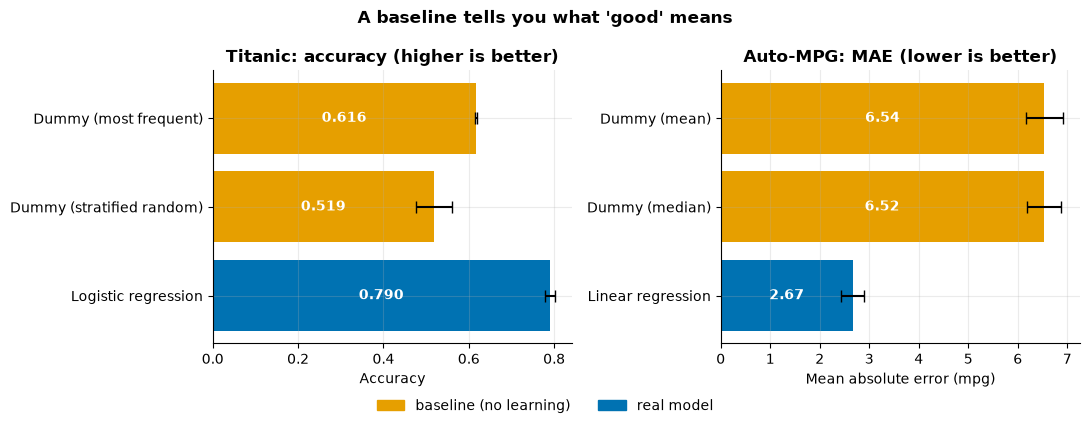

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, scores, title, xlabel in [
    (axes[0], clf_scores, "Titanic: accuracy (higher is better)", "Accuracy"),
    (axes[1], reg_scores, "Auto-MPG: MAE (lower is better)", "Mean absolute error (mpg)"),
]:
    names = list(scores)
    means = [scores[n].mean() for n in names]
    stds = [scores[n].std() for n in names]
    colors = [PALETTE[1] if n.startswith("Dummy") else PALETTE[0] for n in names]
    ax.barh(names, means, xerr=stds, color=colors, capsize=4)
    for i, m in enumerate(means):
        ax.text(m / 2, i, f"{m:.3f}" if m < 1.5 else f"{m:.2f}", va="center", ha="center", color="white",
                fontweight="bold")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
fig.legend(handles=[Patch(color=PALETTE[1], label="baseline (no learning)"), Patch(color=PALETTE[0], label="real model")],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("A baseline tells you what 'good' means", fontweight="bold")
fig.tight_layout()
savefig("baselines")
plt.show()

The majority-class baseline already reaches ~62 % accuracy on Titanic, so "75 % accuracy" is not
as impressive as it sounds. On MPG the mean-predictor is off by ~6.5 mpg on average; the linear
model cuts it by more than half (≈2.7 mpg).

## 3. Tie the metric to the real cost

Accuracy treats every mistake as equal. Real problems rarely do. Suppose (illustratively) missing a
person who needs help (**false negative**) costs 5 units and sending help to someone who did not
need it (**false positive**) costs 1 unit. The expected cost of a decision threshold $t$ is

$$\text{Cost}(t) = c_{FN}\,\text{FN}(t) + c_{FP}\,\text{FP}(t).$$

The best threshold is then *not* 0.5. We estimate costs on a validation set (never the test set!).

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(Xt, yt, test_size=0.3, stratify=yt, random_state=RANDOM_STATE)
logreg = Pipeline([("pre", pre_t), ("model", LogisticRegression(max_iter=1000))]).fit(X_tr, y_tr)
p_val = logreg.predict_proba(X_val)[:, 1]

C_FN, C_FP = 5, 1
thresholds = np.linspace(0.01, 0.99, 99)
fn = np.array([((p_val < t) & (y_val == 1)).sum() for t in thresholds])
fp = np.array([((p_val >= t) & (y_val == 0)).sum() for t in thresholds])
cost = C_FN * fn + C_FP * fp
acc = np.array([((p_val >= t).astype(int) == y_val).mean() for t in thresholds])
t_cost, t_acc = thresholds[cost.argmin()], thresholds[acc.argmax()]
print(f"threshold minimising cost: {t_cost:.2f}  (cost={cost.min()}, accuracy={acc[cost.argmin()]:.3f})")
print(f"threshold maximising accuracy: {t_acc:.2f}  (cost={cost[acc.argmax()]}, accuracy={acc.max():.3f})")

threshold minimising cost: 0.37  (cost=125, accuracy=0.802)
threshold maximising accuracy: 0.51  (cost=160, accuracy=0.806)


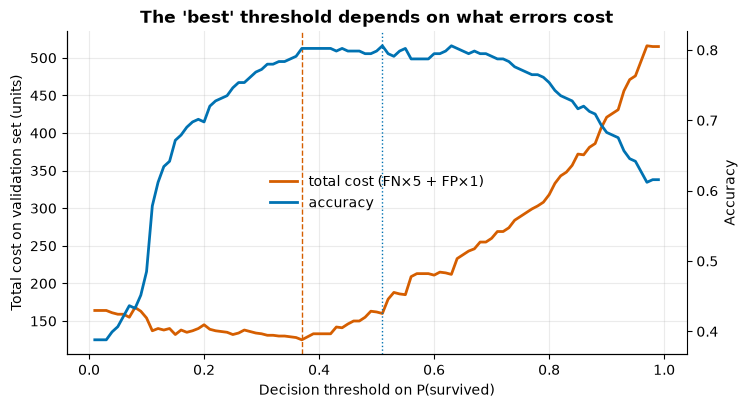

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(thresholds, cost, color=PALETTE[3], lw=2, label=f"total cost (FN×{C_FN} + FP×{C_FP})")
ax1.axvline(t_cost, color=PALETTE[3], ls="--", lw=1)
ax1.set_xlabel("Decision threshold on P(survived)")
ax1.set_ylabel("Total cost on validation set (units)")
ax2 = ax1.twinx()
ax2.plot(thresholds, acc, color=PALETTE[0], lw=2, label="accuracy")
ax2.axvline(t_acc, color=PALETTE[0], ls=":", lw=1)
ax2.set_ylabel("Accuracy")
ax2.grid(False)
ax2.spines["right"].set_visible(True)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center")
ax1.set_title("The 'best' threshold depends on what errors cost")
savefig("cost_vs_threshold")
plt.show()

## 4. Train / validation / test

- **Training set** — the model learns its parameters here.
- **Validation set** — we compare models and tune hyperparameters here (or use cross-validation on train).
- **Test set** — touched **once**, at the very end, to report an unbiased estimate.

Every time we look at a score and change something, that data becomes a little bit "trained on".
Choosing among 100 models on the test set makes the winning test score optimistically biased.
A common split is 60/20/20 (or 80/20 with CV inside the 80).

In [8]:
idx = np.arange(len(titanic))
idx_trval, idx_test = train_test_split(idx, test_size=0.2, stratify=yt, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_trval, test_size=0.25, stratify=yt.iloc[idx_trval],
                                      random_state=RANDOM_STATE)
split_summary = pd.DataFrame({
    "n": [len(idx_train), len(idx_val), len(idx_test)],
    "share": np.round([len(idx_train) / len(idx), len(idx_val) / len(idx), len(idx_test) / len(idx)], 3),
    "survival rate": [yt.iloc[i].mean().round(3) for i in (idx_train, idx_val, idx_test)],
}, index=["train", "validation", "test"])
split_summary

,n,share,survival rate
train,534,0.599,0.384
validation,178,0.200,0.382
test,179,0.201,0.385


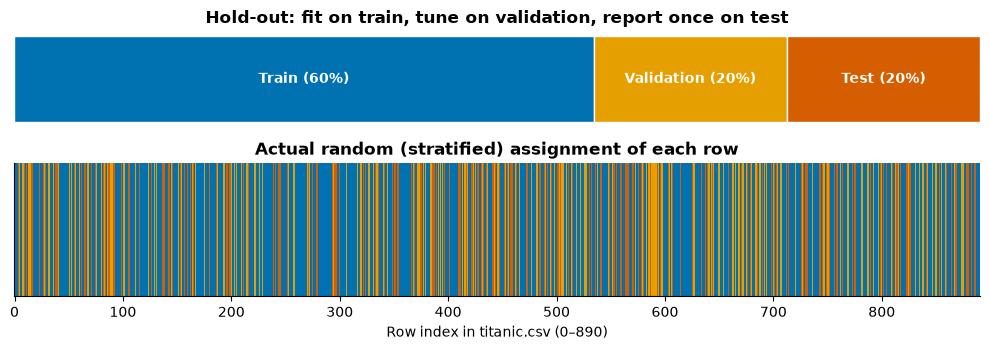

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.6), gridspec_kw={"height_ratios": [1, 1.4]})
# top: conceptual block diagram
ax = axes[0]
blocks = [("Train (60%)", 0, 0.6, PALETTE[0]), ("Validation (20%)", 0.6, 0.2, PALETTE[1]),
          ("Test (20%)", 0.8, 0.2, PALETTE[3])]
for label, start, width, c in blocks:
    ax.barh(0, width, left=start, color=c, edgecolor="white", height=0.8)
    ax.text(start + width / 2, 0, label, ha="center", va="center", color="white", fontweight="bold")
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Hold-out: fit on train, tune on validation, report once on test")
# bottom: the actual shuffled assignment of the 891 rows
ax = axes[1]
assign = np.empty(len(idx), dtype=int)
assign[idx_train], assign[idx_val], assign[idx_test] = 0, 1, 2
from matplotlib.colors import ListedColormap
ax.imshow(assign[None, :], aspect="auto", cmap=ListedColormap([PALETTE[0], PALETTE[1], PALETTE[3]]),
          interpolation="nearest")
ax.set_yticks([]); ax.grid(False)
ax.set_xlabel("Row index in titanic.csv (0–890)")
ax.set_title("Actual random (stratified) assignment of each row")
fig.tight_layout()
savefig("train_val_test_split")
plt.show()

### Stratification

With a small or imbalanced dataset, a purely random split can give folds with noticeably different
class proportions. `stratify=y` (or `StratifiedKFold`) keeps the class ratio the same in every piece.
Below: 200 random 80/20 splits of a small 100-row sample with a 10 % positive class.

random    : positive rate in test ranges 0.00 – 0.25 (std 0.062)
stratified: positive rate in test ranges 0.10 – 0.10 (std 0.000)


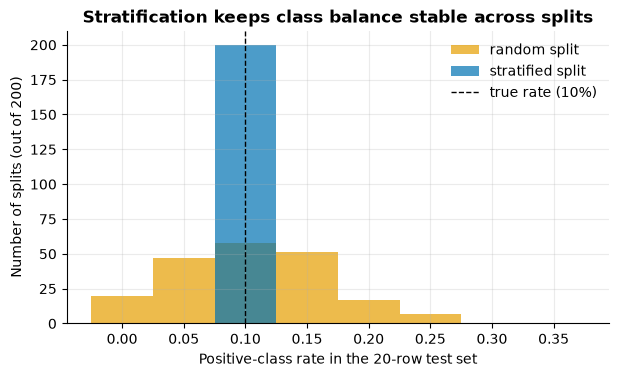

In [10]:
y_small = np.r_[np.ones(10), np.zeros(90)]
rates = {"random": [], "stratified": []}
for seed in range(200):
    _, _, _, yte = train_test_split(y_small, y_small, test_size=0.2, random_state=seed)
    rates["random"].append(yte.mean())
    _, _, _, yte = train_test_split(y_small, y_small, test_size=0.2, random_state=seed, stratify=y_small)
    rates["stratified"].append(yte.mean())
for k, v in rates.items():
    print(f"{k:10s}: positive rate in test ranges {min(v):.2f} – {max(v):.2f} (std {np.std(v):.3f})")

fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.arange(-0.025, 0.4, 0.05)
ax.hist(rates["random"], bins=bins, alpha=0.7, label="random split", color=PALETTE[1])
ax.hist(rates["stratified"], bins=bins, alpha=0.7, label="stratified split", color=PALETTE[0])
ax.axvline(0.10, color="k", ls="--", lw=1, label="true rate (10%)")
ax.set_xlabel("Positive-class rate in the 20-row test set")
ax.set_ylabel("Number of splits (out of 200)")
ax.set_title("Stratification keeps class balance stable across splits")
ax.legend()
savefig("stratification")
plt.show()

## 5. Random vs group vs time-based splits

The split must mimic **how the model will be used**:

| Situation | Risk with random split | Use |
|---|---|---|
| i.i.d. rows | none | `KFold` / `StratifiedKFold` |
| several rows per patient / customer / car model | same entity in train and test → memorisation looks like skill | `GroupKFold`, `GroupShuffleSplit` |
| time-ordered data (sensors, prices) | training on the future to predict the past | `TimeSeriesSplit` |

Below, each row of a plot is one CV iteration; each column is a sample (in index order).

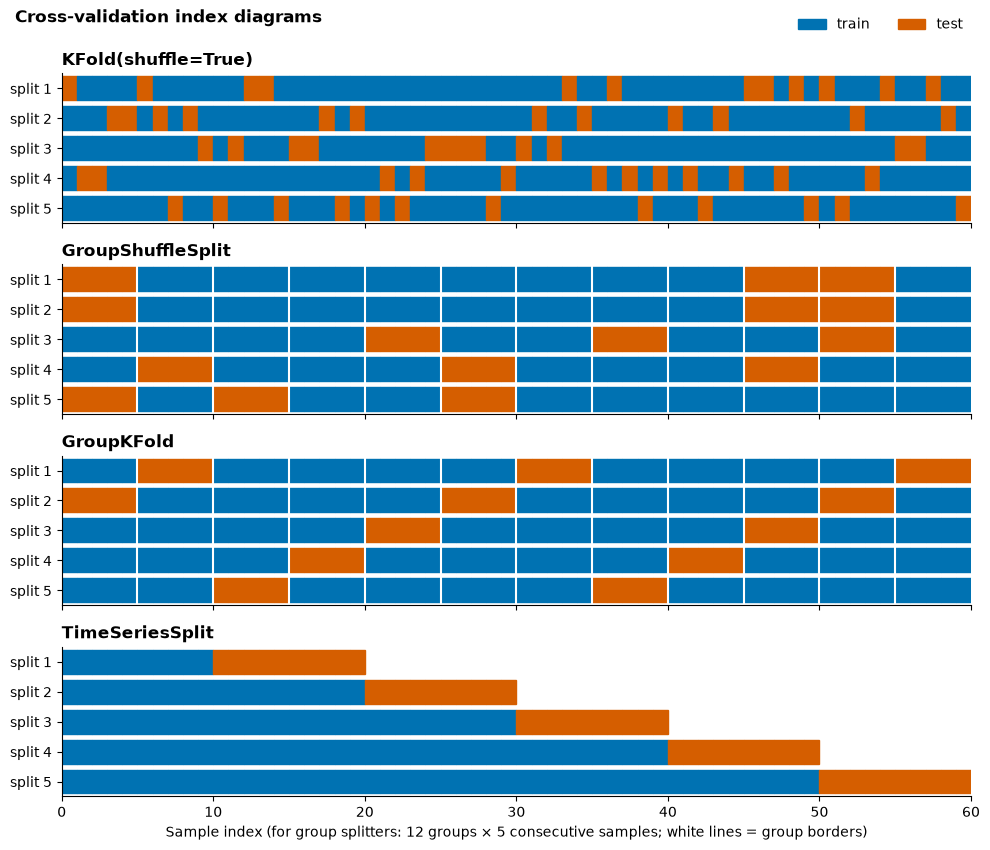

In [11]:
n = 60
groups_demo = np.repeat(np.arange(12), 5)   # 12 "patients" with 5 measurements each
X_demo = np.arange(n).reshape(-1, 1)

splitters = {
    "KFold(shuffle=True)": (KFold(5, shuffle=True, random_state=RANDOM_STATE), None),
    "GroupShuffleSplit": (GroupShuffleSplit(n_splits=5, test_size=0.25, random_state=RANDOM_STATE), groups_demo),
    "GroupKFold": (GroupKFold(5), groups_demo),
    "TimeSeriesSplit": (TimeSeriesSplit(5), None),
}
fig, axes = plt.subplots(len(splitters), 1, figsize=(10, 8.5), sharex=True)
for ax, (name, (splitter, grp)) in zip(axes, splitters.items()):
    for i, (tr, te) in enumerate(splitter.split(X_demo, groups=grp)):
        row = np.full(n, np.nan)
        row[tr], row[te] = 0, 1
        for j in range(n):
            if np.isnan(row[j]):
                continue
            ax.add_patch(plt.Rectangle((j, i + 0.1), 1, 0.8, color=PALETTE[0] if row[j] == 0 else PALETTE[3]))
    ax.set_xlim(0, n); ax.set_ylim(5, 0)
    ax.set_yticks(np.arange(5) + 0.5, [f"split {i+1}" for i in range(5)])
    ax.set_title(name, loc="left")
    ax.grid(False)
    if grp is not None:
        for b in np.arange(5, n, 5):
            ax.axvline(b, color="white", lw=1.5)
axes[-1].set_xlabel("Sample index (for group splitters: 12 groups × 5 consecutive samples; white lines = group borders)")
fig.legend(handles=[Patch(color=PALETTE[0], label="train"), Patch(color=PALETTE[3], label="test")],
           loc="upper right", ncol=2, bbox_to_anchor=(0.98, 1.0))
fig.suptitle("Cross-validation index diagrams", fontweight="bold", x=0.02, ha="left", y=0.995)
fig.tight_layout()
savefig("split_strategies")
plt.show()

Notice: group splitters never cut a group in two; `TimeSeriesSplit` always trains on the past and
tests on the *next* block — the training window grows, and early samples are never tested.

## 6. Data leakage

**Leakage** = information that would not be available at prediction time reaches the model during
training or evaluation. The symptom is always the same: great validation scores, disappointing
production performance.

### Demo 1 — feature selection on pure noise

100 samples, 5 000 features of **pure random noise**, random labels. No model can do better than
50 % on new data. But if we pick the 20 features most correlated with $y$ *using all rows* and then
cross-validate, the selected features are correlated with the labels of the test folds too — by
construction. (This is the classic example from *The Elements of Statistical Learning*, §7.10.2.)

In [12]:
n_samples, n_features = 100, 5000
X_noise = rng.normal(size=(n_samples, n_features))
y_noise = rng.integers(0, 2, size=n_samples)
cv_noise = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# WRONG: select features on the full data, then cross-validate the model only
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
X_selected = selector.transform(X_noise)
wrong = cross_val_score(LogisticRegression(max_iter=1000), X_selected, y_noise, cv=cv_noise)

# RIGHT: selection is a step of the pipeline -> refit inside every training fold
pipe = Pipeline([("select", SelectKBest(f_classif, k=20)), ("model", LogisticRegression(max_iter=1000))])
right = cross_val_score(pipe, X_noise, y_noise, cv=cv_noise)
print(f"WRONG (select, then CV): accuracy = {wrong.mean():.3f} ± {wrong.std():.3f}")
print(f"RIGHT (select inside CV): accuracy = {right.mean():.3f} ± {right.std():.3f}")

WRONG (select, then CV): accuracy = 0.880 ± 0.081
RIGHT (select inside CV): accuracy = 0.530 ± 0.121


One run could be luck, so repeat the whole experiment on 30 fresh noise datasets.

30 repetitions — WRONG: 0.877, RIGHT: 0.522


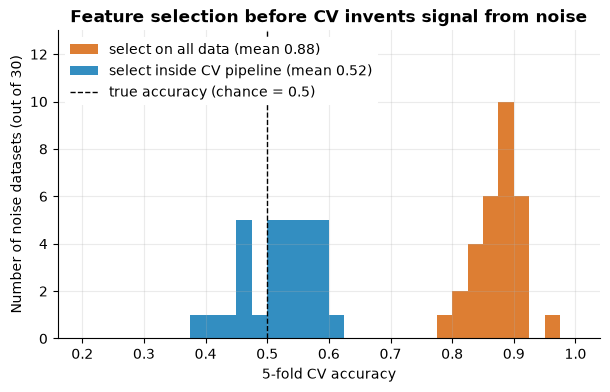

In [13]:
wrong_runs, right_runs = [], []
for rep in range(30):
    r = np.random.default_rng(1000 + rep)
    Xn = r.normal(size=(n_samples, n_features))
    yn = r.integers(0, 2, size=n_samples)
    Xs = SelectKBest(f_classif, k=20).fit_transform(Xn, yn)
    wrong_runs.append(cross_val_score(LogisticRegression(max_iter=1000), Xs, yn, cv=cv_noise).mean())
    right_runs.append(cross_val_score(pipe, Xn, yn, cv=cv_noise).mean())
print(f"30 repetitions — WRONG: {np.mean(wrong_runs):.3f}, RIGHT: {np.mean(right_runs):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0.2, 1.0, 33)
ax.hist(wrong_runs, bins=bins, color=PALETTE[3], alpha=0.8, label=f"select on all data (mean {np.mean(wrong_runs):.2f})")
ax.hist(right_runs, bins=bins, color=PALETTE[0], alpha=0.8, label=f"select inside CV pipeline (mean {np.mean(right_runs):.2f})")
ax.axvline(0.5, color="k", ls="--", lw=1, label="true accuracy (chance = 0.5)")
ax.set_xlabel("5-fold CV accuracy")
ax.set_ylabel("Number of noise datasets (out of 30)")
ax.set_title("Feature selection before CV invents signal from noise")
ax.set_ylim(0, 13)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", framealpha=1)
savefig("leakage_feature_selection")
plt.show()

### Demo 2 — target leakage: a column that *is* the answer

The Titanic CSV contains `alive` ("yes"/"no"), which is just `survived` spelled differently. It
obviously would not exist when we want to make a prediction. Less obvious are `who` and
`adult_male`: they are legitimate (derived from sex and age, known at boarding), but they are
*engineered from other columns* — always ask **when** and **how** a column is created.

In [14]:
print(pd.crosstab(titanic["alive"], titanic["survived"]))

base_cols = ["pclass", "sex", "age", "fare"]
def titanic_pipe(cols):
    cat = [c for c in cols if titanic[c].dtype != "float64" and c not in ("pclass",)]
    num = [c for c in cols if c not in cat]
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])
    return Pipeline([("pre", pre), ("model", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))])

feature_sets = {
    "base features": base_cols,
    "+ who, adult_male": base_cols + ["who", "adult_male"],
    "+ alive (leak!)": base_cols + ["alive"],
}
leak_scores = {}
for name, cols in feature_sets.items():
    leak_scores[name] = cross_val_score(titanic_pipe(cols), titanic[cols], yt, cv=cv, scoring="accuracy")
    print(f"{name:20s} accuracy = {leak_scores[name].mean():.3f} ± {leak_scores[name].std():.3f}")

survived    0    1
alive             
no        549    0
yes         0  342
base features        accuracy = 0.822 ± 0.013
+ who, adult_male    accuracy = 0.832 ± 0.015


+ alive (leak!)      accuracy = 1.000 ± 0.000


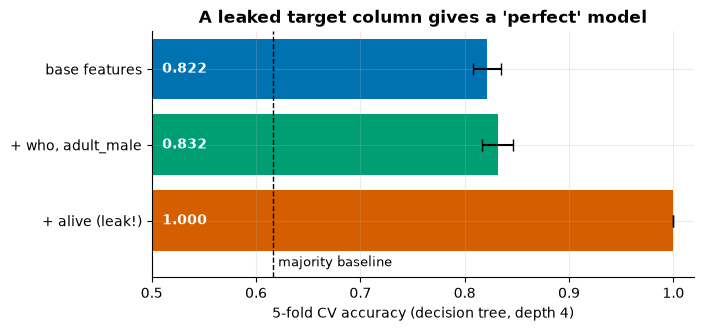

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.2))
names = list(leak_scores)
means = [leak_scores[k].mean() for k in names]
ax.barh(names, means, xerr=[leak_scores[k].std() for k in names], capsize=4,
        color=[PALETTE[0], PALETTE[2], PALETTE[3]])
for i, m in enumerate(means):
    ax.text(0.51, i, f"{m:.3f}", va="center", ha="left", color="white", fontweight="bold")
base_acc = clf_scores["Dummy (most frequent)"].mean()
ax.axvline(base_acc, color="k", ls="--", lw=1)
ax.text(base_acc + 0.005, 2.55, "majority baseline", fontsize=9, va="center")
ax.set_xlim(0.5, 1.02)
ax.set_xlabel("5-fold CV accuracy (decision tree, depth 4)")
ax.set_title("A leaked target column gives a 'perfect' model")
ax.set_ylim(2.75, -0.5)
savefig("target_leakage")
plt.show()

> **Red flag:** a single feature that makes the model (nearly) perfect is far more often a leak than
> a discovery. Check feature importances and ask how that column was recorded.

### Demo 3 — preprocessing fit on all the data

Fitting a `StandardScaler` or `SimpleImputer` on the full dataset lets test-set statistics (means,
standard deviations, medians) shape the training features. For large i.i.d. data the effect is
small; it grows when the dataset is small, when the test distribution differs (e.g. a later time
period), and it becomes severe for *supervised* preprocessing (target encoding, feature selection,
oversampling). The rule is simple: **everything that is `fit` goes inside the pipeline.**

To make the effect visible we use a setting where it matters: a small sample of MPG where the
test cars are the *newest* model years (distribution shift), with a K-nearest-neighbours model
(distance-based, so scaling matters).

In [16]:
mpg_sorted = mpg.sort_values("model_year").reset_index(drop=True)
feat = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
Xs_, ys_ = mpg_sorted[feat], mpg_sorted["mpg"]
cut = int(0.75 * len(mpg_sorted))
X_train3, X_test3, y_train3, y_test3 = Xs_.iloc[:cut], Xs_.iloc[cut:], ys_.iloc[:cut], ys_.iloc[cut:]

# WRONG: imputer + scaler fit on ALL rows, including the future test cars
leaky_pre = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler()).fit(Xs_)
knn = KNeighborsRegressor(n_neighbors=10).fit(leaky_pre.transform(X_train3), y_train3)
mae_wrong = mean_absolute_error(y_test3, knn.predict(leaky_pre.transform(X_test3)))

# RIGHT: everything inside a pipeline fit on the training rows only
good = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), KNeighborsRegressor(n_neighbors=10))
good.fit(X_train3, y_train3)
mae_right = mean_absolute_error(y_test3, good.predict(X_test3))
print(f"test MAE, preprocessing fit on all data : {mae_wrong:.3f} mpg")
print(f"test MAE, preprocessing fit on train only: {mae_right:.3f} mpg")
print("scaler means (leaky vs honest):")
print(pd.DataFrame({"fit on all": leaky_pre[-1].mean_, "fit on train": good[1].mean_}, index=feat).round(1))

test MAE, preprocessing fit on all data : 4.563 mpg
test MAE, preprocessing fit on train only: 4.471 mpg
scaler means (leaky vs honest):
              fit on all  fit on train
cylinders            5.5           5.8
displacement       193.4         214.5
horsepower         104.5         112.1
weight            2970.4        3130.2
acceleration        15.6          15.2
model_year          76.0          74.4


The numbers differ — and importantly the *leaky* number is not the one you would see in production,
where the scaler can only have been fit on the past. Whether leakage makes a score better or worse in
one particular split is incidental; the problem is that **the evaluation no longer simulates reality**.

### Temporal leakage

With time-ordered data, a random split lets the model "interpolate" between yesterday and tomorrow.
Here is a synthetic daily sensor signal (a random walk) predicted from the day number with KNN.

In [17]:
days = np.arange(600)
signal = np.cumsum(rng.normal(0, 1, size=days.size)) + 50
X_time, y_time = days.reshape(-1, 1), signal
knn_t = KNeighborsRegressor(n_neighbors=5)
mae_random = -cross_val_score(knn_t, X_time, y_time, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                              scoring="neg_mean_absolute_error")
mae_ts = -cross_val_score(knn_t, X_time, y_time, cv=TimeSeriesSplit(5), scoring="neg_mean_absolute_error")
print(f"random KFold MAE      : {mae_random.mean():.2f}")
print(f"TimeSeriesSplit MAE   : {mae_ts.mean():.2f}")

random KFold MAE      : 0.78
TimeSeriesSplit MAE   : 4.73


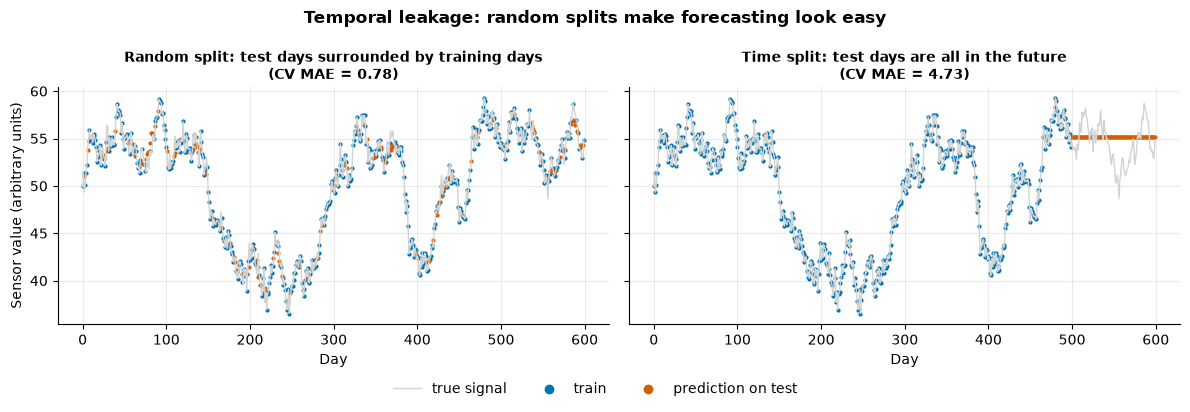

In [18]:
tr, te = list(TimeSeriesSplit(5).split(X_time))[-1]
tr_r, te_r = next(KFold(5, shuffle=True, random_state=RANDOM_STATE).split(X_time))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (a, b), title, m in [(axes[0], (tr_r, te_r), "Random split: test days surrounded by training days", mae_random.mean()),
                             (axes[1], (tr, te), "Time split: test days are all in the future", mae_ts.mean())]:
    model = KNeighborsRegressor(n_neighbors=5).fit(X_time[a], y_time[a])
    ax.plot(days, signal, color="lightgrey", lw=1, label="true signal")
    ax.scatter(days[a], y_time[a], s=4, color=PALETTE[0], label="train")
    ax.scatter(days[b], model.predict(X_time[b]), s=4, color=PALETTE[3], label="prediction on test")
    ax.set_title(f"{title}\n(CV MAE = {m:.2f})", fontsize=10)
    ax.set_xlabel("Day")
axes[0].set_ylabel("Sensor value (arbitrary units)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, markerscale=3, bbox_to_anchor=(0.5, -0.07))
fig.suptitle("Temporal leakage: random splits make forecasting look easy", fontweight="bold")
fig.tight_layout()
savefig("temporal_leakage")
plt.show()

## Key takeaways

- Write down the **target, the metric and the cost of each error type** before modelling.
- Always report a **baseline** (`DummyClassifier`/`DummyRegressor`); a model must beat it clearly.
- Train fits parameters, validation (or CV) chooses models, the **test set is used once**.
- Split the way the model will be used: **stratify** small/imbalanced classes, keep **groups**
  together, never train on the **future**.
- **Leakage** makes offline scores lie. Anything that calls `.fit` — scalers, imputers, feature
  selection, encoders — belongs **inside** a `Pipeline` evaluated with CV.

## Exercises

1. **Baseline for regression.** Replace MAE with $R^2$ for the MPG baselines. What score does
   `DummyRegressor(strategy="mean")` get and why? *Hint: $R^2 = 1 - SS_{res}/SS_{tot}$.*
2. **Cost-sensitive threshold.** Redo the threshold analysis with $c_{FN}=1, c_{FP}=5$. In which
   direction does the optimal threshold move? *Hint: false positives are now expensive.*
3. **Group leakage.** Treat MPG car `name` as a group (some names occur several times). Compare
   `KFold` and `GroupKFold` CV scores of a KNN model. *Hint: `mpg["name"].value_counts()`.*
4. **Noise demo scale.** In Demo 1, vary `k` (number of selected features) and `n_features`. When
   is the fake accuracy highest? *Hint: more candidate features → more chances for spurious correlation.*
5. **Find the leak.** Add a feature `fare_per_survivor_group = fare / titanic.groupby('survived')['fare'].transform('mean')`.
   Why is this a leak, even though it looks like a harmless ratio? *Hint: which column was used in `groupby`?*